In [ ]:
from preprocessing_functions import *
from processing import *

data_P2_pre_training = scipy.io.loadmat(r"C:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\stroke-rehab\P2_pre_training.mat")
data_P2_pre_test = scipy.io.loadmat(r"C:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\stroke-rehab\P2_pre_test.mat")
data_P2_post_training = scipy.io.loadmat(r"C:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\stroke-rehab\P2_post_training.mat")
data_P2_post_test = scipy.io.loadmat(r"C:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\stroke-rehab\P2_post_test.mat")

In [ ]:
fs = data_P2_pre_training["fs"][0][0] 

trig_pre_training = data_P2_pre_training['trig']
y_pre_training = data_P2_pre_training['y']

trig_pre_training = trig_pre_training.T
print(trig_pre_training.shape)

trig_pre_test = data_P2_pre_test['trig']
y_pre_test = data_P2_pre_test['y']

print(trig_pre_test.shape)

trig_post_training = data_P2_post_training['trig']
y_post_training = data_P2_post_training['y']    

print(trig_post_training.shape)

trig_post_test = data_P2_post_test['trig']
y_post_test = data_P2_post_test['y']    

print(trig_post_test.shape)

(223112, 1)
(199552, 1)
(216720, 1)
(233576, 1)


In [ ]:
trigger_events_time_pre_training = get_trigger_onsets(trig_pre_training, fs)
trigger_events_time_pre_test = get_trigger_onsets(trig_pre_test, fs)
trigger_events_time_post_training = get_trigger_onsets(trig_post_training, fs)
trigger_events_time_post_test = get_trigger_onsets(trig_post_test, fs)

In [ ]:
y_pre_training_trimmed = trim_data(y_pre_training, fs, start_time = trigger_events_time_pre_training[0] - 1)
y_pre_test_trimmed = trim_data(y_pre_test, fs, start_time = trigger_events_time_pre_test[0] - 1)
y_post_training_trimmed = trim_data(y_post_training, fs, start_time = trigger_events_time_post_training[0] - 1)
y_post_test_trimmed = trim_data(y_post_test, fs, start_time = trigger_events_time_post_test[0] - 1)


trigger_events_trimmed_pre_training = trim_data(trig_pre_training, fs, start_time = trigger_events_time_pre_training[0] - 1)
trigger_events_trimmed_pre_test = trim_data(trig_pre_test, fs, start_time = trigger_events_time_pre_test[0] - 1)
trigger_events_trimmed_post_training = trim_data(trig_post_training, fs, start_time = trigger_events_time_post_training[0] - 1)
trigger_events_trimmed_post_test = trim_data(trig_post_test, fs, start_time = trigger_events_time_post_test[0] - 1)

t_trimmed = np.arange(y_pre_training.shape[0]) / fs

In [ ]:
y_pre_training_trimmed = notch_filter(y_pre_training_trimmed, fs, notch_freq = 50)
y_pre_training_trimmed = notch_filter(y_pre_training_trimmed, fs, notch_freq = 60)
y_pre_training_trimmed = bandpass_filter(y_pre_training_trimmed, fs, lowcut=1, highcut=40, order=4)

print(y_pre_training_trimmed.shape)

y_pre_test_trimmed = notch_filter(y_pre_test_trimmed, fs, notch_freq = 50)
y_pre_test_trimmed = notch_filter(y_pre_test_trimmed, fs, notch_freq = 60)
y_pre_test_trimmed = bandpass_filter(y_pre_test_trimmed, fs, lowcut=1, highcut=40, order=4)

y_post_training_trimmed = notch_filter(y_post_training_trimmed, fs, notch_freq = 50)
y_post_training_trimmed = notch_filter(y_post_training_trimmed, fs, notch_freq = 60)
y_post_training_trimmed = bandpass_filter(y_post_training_trimmed, fs, lowcut=1, highcut=40, order=4)

y_post_test_trimmed = notch_filter(y_post_test_trimmed, fs, notch_freq = 50)
y_post_test_trimmed = notch_filter(y_post_test_trimmed, fs, notch_freq = 60)
y_post_test_trimmed = bandpass_filter(y_post_test_trimmed, fs, lowcut=1, highcut=40, order=4)    

(210416, 16)


In [ ]:
print(y_pre_training.shape)

right_hand_epochs_p2_pre_training, left_hand_epochs_p2_pre_training = epoch_data(y_pre_training_trimmed, trigger_events_trimmed_pre_training, fs, time_after=2.0, period_of_interest=6.0)
right_hand_epochs_p2_pre_test, left_hand_epochs_p2_pre_test = epoch_data(y_pre_test_trimmed, trigger_events_trimmed_pre_test, fs, time_after=2.0, period_of_interest=6.0)
right_hand_epochs_p2_post_training, left_hand_epochs_p2_post_training = epoch_data(y_post_training_trimmed, trigger_events_trimmed_post_training, fs, time_after=2.0, period_of_interest=6.0)
right_hand_epochs_p2_post_test, left_hand_epochs_p2_post_test = epoch_data(y_post_test_trimmed, trigger_events_trimmed_post_test, fs, time_after=2.0, period_of_interest=6.0)

print(right_hand_epochs_p2_pre_training.shape)

(223112, 16)
(40, 1536, 16)


In [ ]:
CHANNEL_NAMES = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','Pz']

info = mne.create_info(ch_names=CHANNEL_NAMES, sfreq=fs, ch_types='eeg')

montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

<Info | 8 non-empty values
 bads: []
 ch_names: FC3, FCz, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, CP1, CPz, CP2, ...
 chs: 16 EEG
 custom_ref_applied: False
 dig: 19 items (3 Cardinal, 16 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 16
 projs: []
 sfreq: 256.0 Hz
>

In [ ]:
right_hand_epochs_p2_pre_training = autoreject_epochs(right_hand_epochs_p2_pre_training, info=info)
left_hand_epochs_p2_pre_training = autoreject_epochs(left_hand_epochs_p2_pre_training, info=info)
right_hand_epochs_p2_pre_test = autoreject_epochs(right_hand_epochs_p2_pre_test, info=info)
left_hand_epochs_p2_pre_test = autoreject_epochs(left_hand_epochs_p2_pre_test, info=info)
right_hand_epochs_p2_post_training = autoreject_epochs(right_hand_epochs_p2_post_training, info=info)
left_hand_epochs_p2_post_training = autoreject_epochs(left_hand_epochs_p2_post_training, info=info)
right_hand_epochs_p2_post_test = autoreject_epochs(right_hand_epochs_p2_post_test, info=info)
left_hand_epochs_p2_post_test = autoreject_epochs(left_hand_epochs_p2_post_test, info=info)

Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated


c:\Users\rodri\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running autoreject on ch_type=eeg


100%|██████████| Creating augmented epochs : 16/16 [00:00<00:00,   69.26it/s]
100%|██████████| Computing thresholds ... : 16/16 [00:11<00:00,    1.40it/s]











100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  217.98it/s]













100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  166.27it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    7.73it/s]














100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  158.87it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    9.69it/s]














100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  159.08it/s]












100%|██████████| Fold : 10/10 [00:00<00:00,   72.91it/s]
100%|██████████| n_interp : 3/3 [00:03<00:00,    1.13s/it]






Estimated consensus=0.80 and n_interpolate=4


...

AutoReject: 40 → 39 epochs
Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
Running autoreject on ch_type=eeg


100%|██████████| Creating augmented epochs : 16/16 [00:00<00:00,  106.50it/s]
100%|██████████| Computing thresholds ... : 16/16 [00:08<00:00,    1.84it/s]












100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  188.66it/s]















100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  149.27it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    7.63it/s]














100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  154.23it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    9.35it/s]

c:\Users\rodri\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\rodri\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)












100%|██████████| Repairing epochs : 





Estimated consensus=0.40 and n_interpolate=4















100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  175.83it/s]

Dropped 4 epochs: 3, 8, 23, 38
AutoReject: 40 → 36 epochs


In [ ]:
import json
import numpy as np

data_to_save = {
    "right_hand_epochs": right_hand_epochs_p2_pre_training.tolist(),
    "left_hand_epochs": left_hand_epochs_p2_pre_training.tolist(),
    "labels": {
        "right": -1,
        "left": 1
    },
    "shape_info": {
        "format": "(epochs, samples, channels)",
        "right_shape": right_hand_epochs_p2_pre_training.shape,
        "left_shape": left_hand_epochs_p2_pre_training.shape
    }
}

with open("P2_pre_training_epochs_clean.json", "w") as f:
    json.dump(data_to_save, f)

print("Saved successfully!")


data_to_save = {
    "right_hand_epochs": right_hand_epochs_p2_pre_test.tolist(),
    "left_hand_epochs": left_hand_epochs_p2_pre_test.tolist(),
    "labels": {
        "right": -1,
        "left": 1
    },
    "shape_info": {
        "format": "(epochs, samples, channels)",
        "right_shape": right_hand_epochs_p2_pre_test.shape,
        "left_shape": left_hand_epochs_p2_pre_test.shape
    }
}

with open("P2_pre_test_epochs_clean.json", "w") as f:
    json.dump(data_to_save, f)

print("Saved successfully!")


data_to_save = {
    "right_hand_epochs": right_hand_epochs_p2_post_training.tolist(),
    "left_hand_epochs": left_hand_epochs_p2_post_training.tolist(),
    "labels": {
        "right": -1,
        "left": 1
    },
    "shape_info": {
        "format": "(epochs, samples, channels)",
        "right_shape": right_hand_epochs_p2_post_training.shape,
        "left_shape": left_hand_epochs_p2_post_training.shape
    }
}

with open("P2_post_training_epochs_clean.json", "w") as f:
    json.dump(data_to_save, f)

print("Saved successfully!")


data_to_save = {
    "right_hand_epochs": right_hand_epochs_p2_post_test.tolist(),
    "left_hand_epochs": left_hand_epochs_p2_post_test.tolist(),
    "labels": {
        "right": -1,
        "left": 1
    },
    "shape_info": {
        "format": "(epochs, samples, channels)",
        "right_shape": right_hand_epochs_p2_post_test.shape,
        "left_shape": left_hand_epochs_p2_post_test.shape
    }
}

with open("P2_post_test_epochs_clean.json", "w") as f:
    json.dump(data_to_save, f)

print("Saved successfully!")

Saved successfully!
Saved successfully!
Saved successfully!
Saved successfully!


In [ ]:
mu_left_pre_training = get_band_power(left_hand_epochs_p2_pre_training, fs=256, low=8, high=12)
mu_right_pre_training = get_band_power(right_hand_epochs_p2_pre_training, fs=256, low=8, high=12)

beta_left_pre_training = get_band_power(left_hand_epochs_p2_pre_training, fs=256, low=13, high=30)
beta_right_pre_training = get_band_power(right_hand_epochs_p2_pre_training, fs=256, low=13, high=30)



mu_left_pre_test = get_band_power(left_hand_epochs_p2_pre_test, fs=256, low=8, high=12)
mu_right_pre_test = get_band_power(right_hand_epochs_p2_pre_test, fs=256, low=8, high=12)

beta_left_pre_test = get_band_power(left_hand_epochs_p2_pre_test, fs=256, low=13, high=30)
beta_right_pre_test = get_band_power(right_hand_epochs_p2_pre_test, fs=256, low=13, high=30)



mu_left_post_training = get_band_power(left_hand_epochs_p2_post_training, fs=256, low=8, high=12)
mu_right_post_training = get_band_power(right_hand_epochs_p2_post_training, fs=256, low=8, high=12)

beta_left_post_training = get_band_power(left_hand_epochs_p2_post_training, fs=256, low=13, high=30)
beta_right_post_training = get_band_power(right_hand_epochs_p2_post_training, fs=256, low=13, high=30)



mu_left_post_test = get_band_power(left_hand_epochs_p2_post_test, fs=256, low=8, high=12)
mu_right_post_test = get_band_power(right_hand_epochs_p2_post_test, fs=256, low=8, high=12)

beta_left_post_test = get_band_power(left_hand_epochs_p2_post_test, fs=256, low=13, high=30)
beta_right_post_test = get_band_power(right_hand_epochs_p2_post_test, fs=256, low=13, high=30)

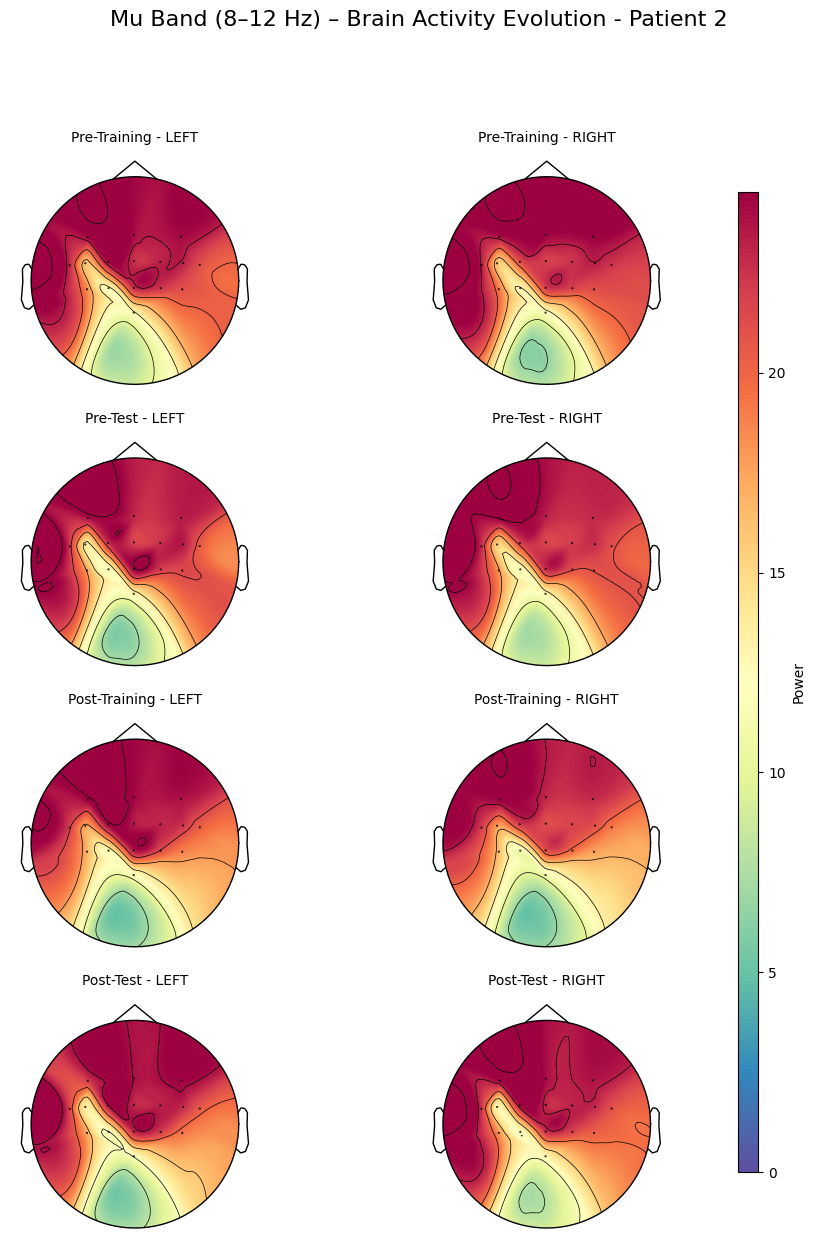

In [ ]:
fig_mu, axes = plt.subplots(4, 2, figsize=(10, 14))

conditions = [
    ("Pre-Training", mu_left_pre_training, mu_right_pre_training),
    ("Pre-Test", mu_left_pre_test, mu_right_pre_test),
    ("Post-Training", mu_left_post_training, mu_right_post_training),
    ("Post-Test", mu_left_post_test, mu_right_post_test),
]

for i, (label, left_data, right_data) in enumerate(conditions):

    im, _ = mne.viz.plot_topomap(left_data, info, axes=axes[i, 0],
                                 show=False, cmap='Spectral_r')
    axes[i, 0].set_title(f"{label} - LEFT", fontsize=10)

    mne.viz.plot_topomap(right_data, info, axes=axes[i, 1],
                         show=False, cmap='Spectral_r')
    axes[i, 1].set_title(f"{label} - RIGHT", fontsize=10)

fig_mu.subplots_adjust(right=0.88)

cbar_ax = fig_mu.add_axes([0.9, 0.15, 0.02, 0.7])
fig_mu.colorbar(im, cax=cbar_ax, label='Power')

fig_mu.suptitle("Mu Band (8–12 Hz) – Brain Activity Evolution - Patient 2",
fontsize=16,
x=0.58,   # horizontal center
y=0.98,  # vertical position (adjust if needed)
ha='center'
)
plt.show()

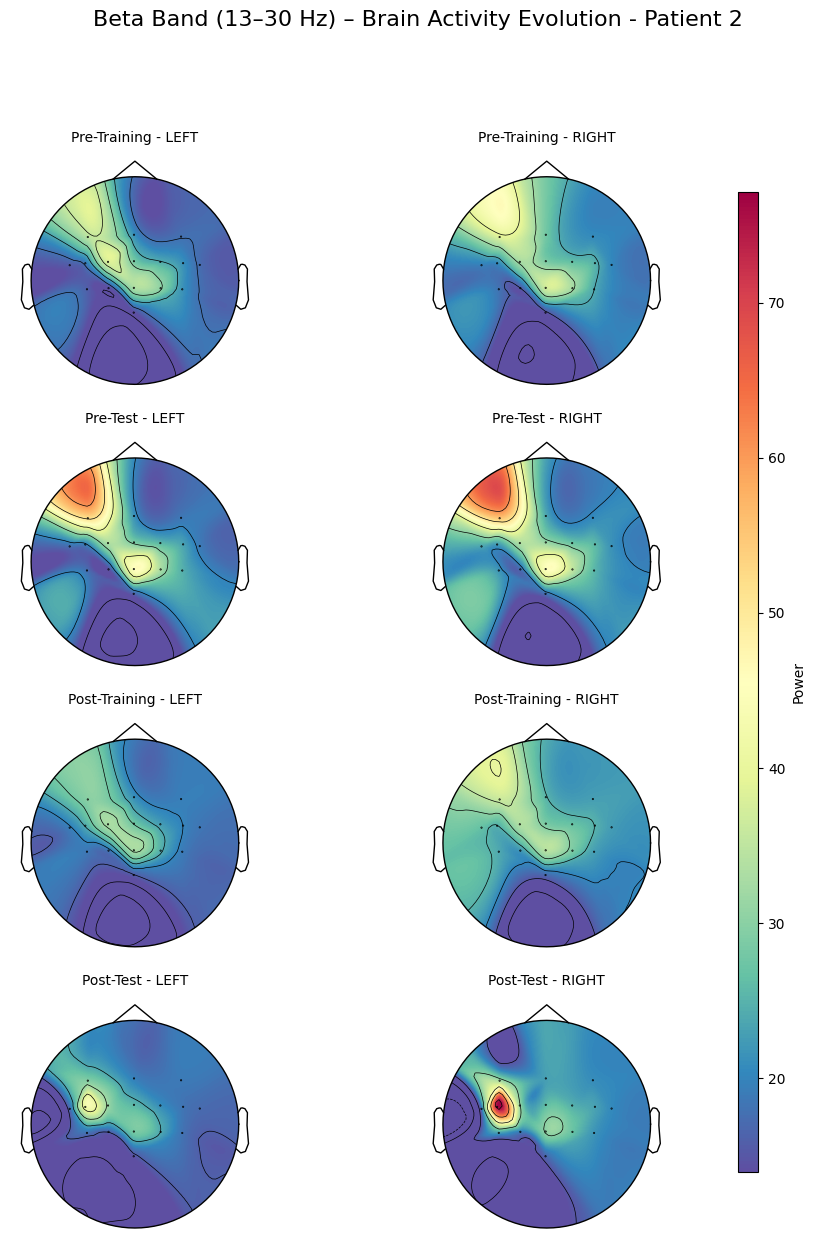

In [ ]:
fig_beta, axes = plt.subplots(4, 2, figsize=(10, 14))

conditions = [
    ("Pre-Training", beta_left_pre_training, beta_right_pre_training),
    ("Pre-Test", beta_left_pre_test, beta_right_pre_test),
    ("Post-Training", beta_left_post_training, beta_right_post_training),
    ("Post-Test", beta_left_post_test, beta_right_post_test),
]

# Optional but recommended: consistent color scale
vmin = min([d.min() for _, l, r in conditions for d in (l, r)])
vmax = max([d.max() for _, l, r in conditions for d in (l, r)])

for i, (label, left_data, right_data) in enumerate(conditions):

    im, _ = mne.viz.plot_topomap(
        left_data, info,
        axes=axes[i, 0],
        show=False,
        cmap='Spectral_r',
        vlim=(vmin, vmax)
    )
    axes[i, 0].set_title(f"{label} - LEFT", fontsize=10)

    mne.viz.plot_topomap(
        right_data, info,
        axes=axes[i, 1],
        show=False,
        cmap='Spectral_r',
        vlim=(vmin, vmax)
    )
    axes[i, 1].set_title(f"{label} - RIGHT", fontsize=10)

# 🔥 Make space for colorbar
fig_beta.subplots_adjust(right=0.88)

# 🔥 Dedicated colorbar axis (no overlap)
cbar_ax = fig_beta.add_axes([0.9, 0.15, 0.02, 0.7])
fig_beta.colorbar(im, cax=cbar_ax, label='Power')

fig_beta.suptitle("Beta Band (13–30 Hz) – Brain Activity Evolution - Patient 2",
fontsize=16,
x=0.58,   # horizontal center
y=0.98,  # vertical position (adjust if needed)
ha='center'
)

plt.show()

In [ ]:
ref_right_pre_training, ref_left_pre_training = epoch_data(
    y_pre_training_trimmed,
    trigger_events_trimmed_pre_training,
    fs,
    time_after=-1.0,
    period_of_interest=1.0
)

mu_erd_left_pre_training = calculate_erd_ers(left_hand_epochs_p2_pre_training, ref_left_pre_training, fs, 8, 12)
mu_erd_right_pre_training = calculate_erd_ers(right_hand_epochs_p2_pre_training, ref_right_pre_training, fs, 8, 12)

beta_erd_left_pre_training = calculate_erd_ers(left_hand_epochs_p2_pre_training, ref_left_pre_training, fs, 13, 30)
beta_erd_right_pre_training = calculate_erd_ers(right_hand_epochs_p2_pre_training, ref_right_pre_training, fs, 13, 30)



ref_right_pre_test, ref_left_pre_test = epoch_data(
    y_pre_test_trimmed,
    trigger_events_trimmed_pre_test,
    fs,
    time_after=-1.0,
    period_of_interest=1.0
)

mu_erd_left_pre_test = calculate_erd_ers(left_hand_epochs_p2_pre_test, ref_left_pre_test, fs, 8, 12)
mu_erd_right_pre_test = calculate_erd_ers(right_hand_epochs_p2_pre_test, ref_right_pre_test, fs, 8, 12)

beta_erd_left_pre_test = calculate_erd_ers(left_hand_epochs_p2_pre_test, ref_left_pre_test, fs, 13, 30)
beta_erd_right_pre_test = calculate_erd_ers(right_hand_epochs_p2_pre_test, ref_right_pre_test, fs, 13, 30)



ref_right_post_training, ref_left_post_training = epoch_data(
    y_post_training_trimmed,
    trigger_events_trimmed_post_training,
    fs,
    time_after=-1.0,
    period_of_interest=1.0
)

mu_erd_left_post_training = calculate_erd_ers(left_hand_epochs_p2_post_training, ref_left_post_training, fs, 8, 12)
mu_erd_right_post_training = calculate_erd_ers(right_hand_epochs_p2_post_training, ref_right_post_training, fs, 8, 12)

beta_erd_left_post_training = calculate_erd_ers(left_hand_epochs_p2_post_training, ref_left_post_training, fs, 13, 30)
beta_erd_right_post_training = calculate_erd_ers(right_hand_epochs_p2_post_training, ref_right_post_training, fs, 13, 30)



ref_right_post_test, ref_left_post_test = epoch_data(
    y_post_test_trimmed,
    trigger_events_trimmed_post_test,
    fs,
    time_after=-1.0,
    period_of_interest=1.0
)

mu_erd_left_post_test = calculate_erd_ers(left_hand_epochs_p2_post_test, ref_left_post_test, fs, 8, 12)
mu_erd_right_post_test = calculate_erd_ers(right_hand_epochs_p2_post_test, ref_right_post_test, fs, 8, 12)

beta_erd_left_post_test = calculate_erd_ers(left_hand_epochs_p2_post_test, ref_left_post_test, fs, 13, 30)
beta_erd_right_post_test = calculate_erd_ers(right_hand_epochs_p2_post_test, ref_right_post_test, fs, 13, 30)

c:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\processing.py:76: UserWarning: nperseg=512 is greater than signal length max(len(x), len(y)) = 256, using nperseg = 256
  f, Pxx = welch(epoch[:, ch], fs=fs, nperseg=fs*2)


In [ ]:
data_p2 = {
    "pre_training": {
        "mu": {
            "left": np.array(mu_erd_left_pre_training).tolist(),
            "right": np.array(mu_erd_right_pre_training).tolist(),
        },
        "beta": {
            "left": np.array(beta_erd_left_pre_training).tolist(),
            "right": np.array(beta_erd_right_pre_training).tolist(),
        },
    },

    "pre_test": {
        "mu": {
            "left": np.array(mu_erd_left_pre_test).tolist(),
            "right": np.array(mu_erd_right_pre_test).tolist(),
        },
        "beta": {
            "left": np.array(beta_erd_left_pre_test).tolist(),
            "right": np.array(beta_erd_right_pre_test).tolist(),
        },
    },

    "post_training": {
        "mu": {
            "left": np.array(mu_erd_left_post_training).tolist(),
            "right": np.array(mu_erd_right_post_training).tolist(),
        },
        "beta": {
            "left": np.array(beta_erd_left_post_training).tolist(),
            "right": np.array(beta_erd_right_post_training).tolist(),
        },
    },

    "post_test": {
        "mu": {
            "left": np.array(mu_erd_left_post_test).tolist(),
            "right": np.array(mu_erd_right_post_test).tolist(),
        },
        "beta": {
            "left": np.array(beta_erd_left_post_test).tolist(),
            "right": np.array(beta_erd_right_post_test).tolist(),
        },
    },
}

with open("p2_erd_ers.json", "w") as f:
    json.dump(data_p2, f, indent=4)

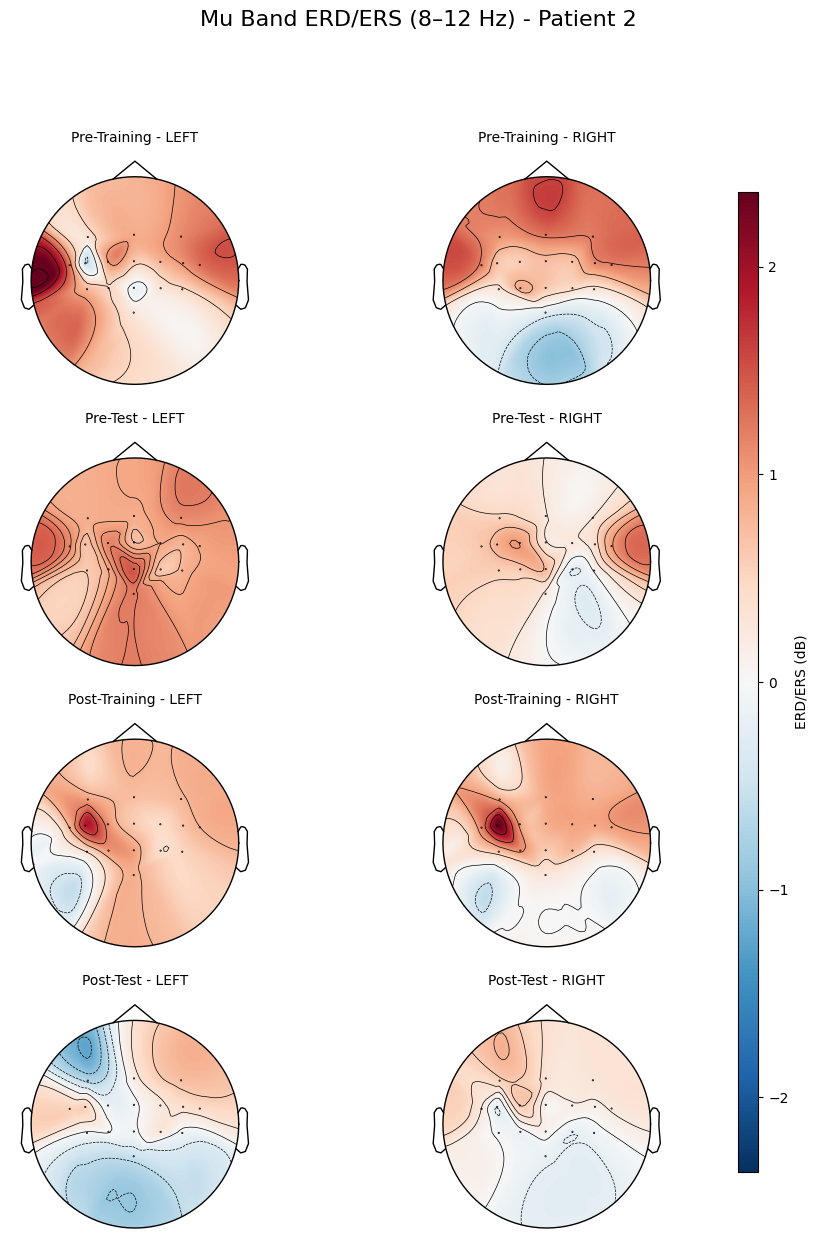

In [ ]:
fig_mu, axes = plt.subplots(4, 2, figsize=(10, 14))

conditions = [
    ("Pre-Training", mu_erd_left_pre_training, mu_erd_right_pre_training),
    ("Pre-Test", mu_erd_left_pre_test, mu_erd_right_pre_test),
    ("Post-Training", mu_erd_left_post_training, mu_erd_right_post_training),
    ("Post-Test", mu_erd_left_post_test, mu_erd_right_post_test),
]

all_data = [d for _, l, r in conditions for d in (l, r)]
vmax = max(abs(d).max() for d in all_data)
vmin = -vmax

for i, (label, left_data, right_data) in enumerate(conditions):

    im, _ = mne.viz.plot_topomap(
        left_data, info,
        axes=axes[i, 0],
        show=False,
        cmap='RdBu_r',
        vlim=(vmin, vmax)
    )
    axes[i, 0].set_title(f"{label} - LEFT", fontsize=10)

    mne.viz.plot_topomap(
        right_data, info,
        axes=axes[i, 1],
        show=False,
        cmap='RdBu_r',
        vlim=(vmin, vmax)
    )
    axes[i, 1].set_title(f"{label} - RIGHT", fontsize=10)

# colorbar outside
fig_mu.subplots_adjust(right=0.88)
cbar_ax = fig_mu.add_axes([0.9, 0.15, 0.02, 0.7])
fig_mu.colorbar(im, cax=cbar_ax, label='ERD/ERS (dB)')

fig_mu.suptitle("Mu Band ERD/ERS (8–12 Hz) - Patient 2",
fontsize=16,
x=0.58,   # horizontal center
y=0.98,  # vertical position (adjust if needed)
ha='center'
)

plt.show()

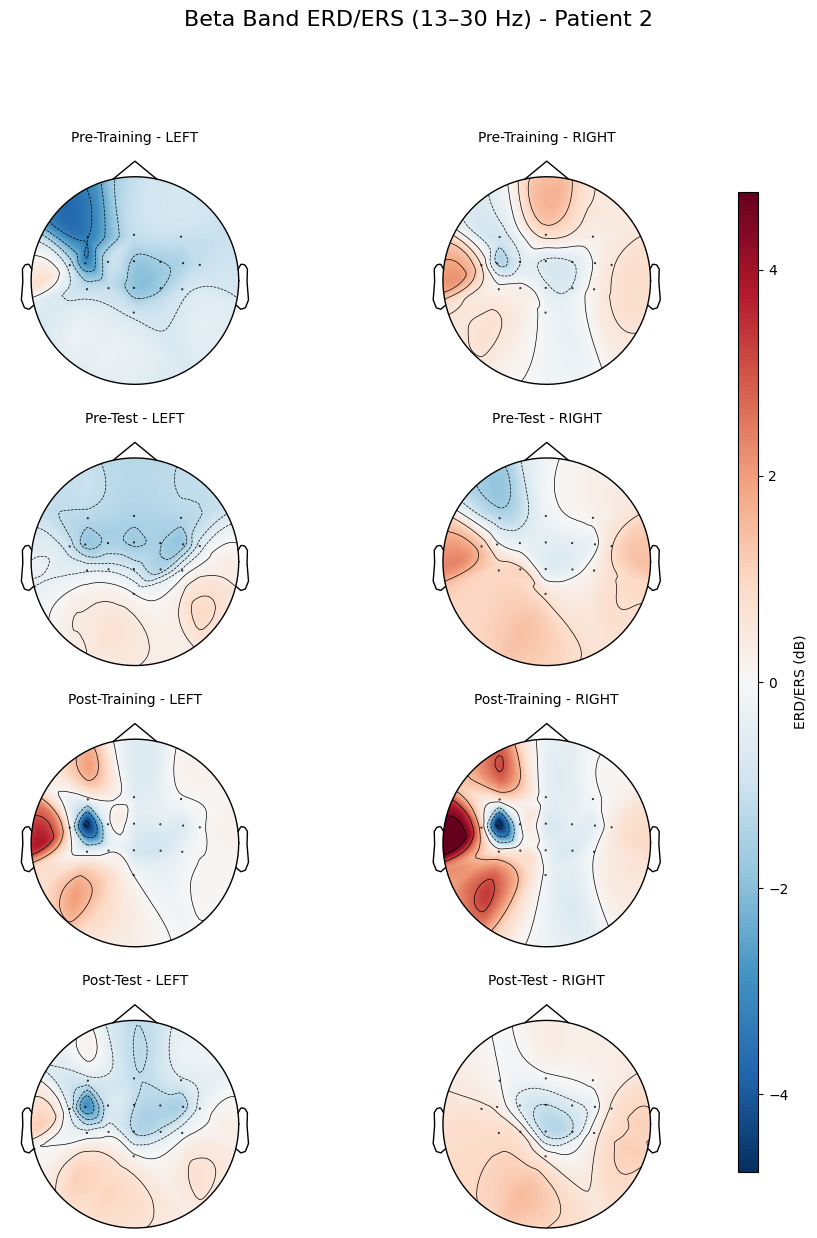

In [ ]:
fig_beta, axes = plt.subplots(4, 2, figsize=(10, 14))

conditions = [
    ("Pre-Training", beta_erd_left_pre_training, beta_erd_right_pre_training),
    ("Pre-Test", beta_erd_left_pre_test, beta_erd_right_pre_test),
    ("Post-Training", beta_erd_left_post_training, beta_erd_right_post_training),
    ("Post-Test", beta_erd_left_post_test, beta_erd_right_post_test),
]

all_data = [d for _, l, r in conditions for d in (l, r)]
vmax = max(abs(d).max() for d in all_data)
vmin = -vmax

for i, (label, left_data, right_data) in enumerate(conditions):

    im, _ = mne.viz.plot_topomap(
        left_data, info,
        axes=axes[i, 0],
        show=False,
        cmap='RdBu_r',
        vlim=(vmin, vmax)
    )
    axes[i, 0].set_title(f"{label} - LEFT", fontsize=10)

    mne.viz.plot_topomap(
        right_data, info,
        axes=axes[i, 1],
        show=False,
        cmap='RdBu_r',
        vlim=(vmin, vmax)
    )
    axes[i, 1].set_title(f"{label} - RIGHT", fontsize=10)

fig_beta.subplots_adjust(right=0.88)
cbar_ax = fig_beta.add_axes([0.9, 0.15, 0.02, 0.7])
fig_beta.colorbar(im, cax=cbar_ax, label='ERD/ERS (dB)')

fig_beta.suptitle("Beta Band ERD/ERS (13–30 Hz) - Patient 2",
fontsize=16,
x=0.58,   # horizontal center
y=0.98,  # vertical position (adjust if needed)
ha='center'
)

plt.show()